# 03 — Feature Engineering
Construção do dataset analítico com todas as features para modelagem.  
Saída: `data/processed/dataset_modelagem.parquet`


## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

BASE_DIR  = Path().resolve().parent
RAW_DIR   = BASE_DIR / 'data' / 'raw'
PROC_DIR  = BASE_DIR / 'data' / 'processed'
OUT_DIR   = BASE_DIR / 'outputs'
PROC_DIR.mkdir(exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.35,
                     'axes.spines.top': False, 'axes.spines.right': False})
print("OK")


OK


## 1. Carga e Merge Base

In [2]:
df_pld    = pd.read_parquet(RAW_DIR / 'pld_mensal_raw.parquet')
df_ear    = pd.read_parquet(RAW_DIR / 'ear_mensal_raw.parquet')
df_ena    = pd.read_parquet(RAW_DIR / 'ena_mensal_raw.parquet')
df_term   = pd.read_parquet(RAW_DIR / 'termica_mensal_raw.parquet')
df_precip = pd.read_parquet(RAW_DIR / 'precipitacao_mensal_raw.parquet')

df = (df_pld[['din_referencia','val_pld']]
      .merge(df_ear,    on='din_referencia')
      .merge(df_ena,    on='din_referencia')
      .merge(df_term,   on='din_referencia')
      .merge(df_precip, on='din_referencia')
      .sort_values('din_referencia').reset_index(drop=True))

print(f"Base: {df.shape} | {df['din_referencia'].min():%b/%Y} → {df['din_referencia'].max():%b/%Y}")


Base: (120, 6) | Jan/2015 → Dec/2024


## 2. Features de Calendário e Sazonalidade

In [3]:
# ── Calendário ──────────────────────────────────────────────────────────
df['ano']        = df['din_referencia'].dt.year
df['mes']        = df['din_referencia'].dt.month
df['trimestre']  = df['din_referencia'].dt.quarter

# ── Sazonalidade via Fourier (captura padrão senoidal suave) ─────────────
df['sin_mes_1']  = np.sin(2 * np.pi * df['mes'] / 12)
df['cos_mes_1']  = np.cos(2 * np.pi * df['mes'] / 12)
df['sin_mes_2']  = np.sin(4 * np.pi * df['mes'] / 12)
df['cos_mes_2']  = np.cos(4 * np.pi * df['mes'] / 12)

# ── Flag período seco (mai–out) ──────────────────────────────────────────
df['periodo_seco'] = df['mes'].between(5, 10).astype(int)

print("Features de calendário criadas ✅")


Features de calendário criadas ✅


## 3. Lags e Médias Móveis do PLD

In [4]:
# ── Lags do target (PLD) ─────────────────────────────────────────────────
for lag in [1, 2, 3, 6, 12]:
    df[f'pld_lag_{lag}'] = df['val_pld'].shift(lag)

# ── Médias móveis ─────────────────────────────────────────────────────────
df['pld_mm3']  = df['val_pld'].shift(1).rolling(3).mean()
df['pld_mm6']  = df['val_pld'].shift(1).rolling(6).mean()
df['pld_mm12'] = df['val_pld'].shift(1).rolling(12).mean()

# ── Desvio padrão móvel (volatilidade) ───────────────────────────────────
df['pld_std6'] = df['val_pld'].shift(1).rolling(6).std()

print("Lags e médias móveis criados ✅")
print(f"Features PLD: {[c for c in df.columns if 'pld' in c and c != 'val_pld']}")


Lags e médias móveis criados ✅
Features PLD: ['pld_lag_1', 'pld_lag_2', 'pld_lag_3', 'pld_lag_6', 'pld_lag_12', 'pld_mm3', 'pld_mm6', 'pld_mm12', 'pld_std6']


## 4. Lags das Variáveis Exógenas

In [5]:
# EAR: informação do mês anterior e tendência
df['ear_lag1']    = df['ear_pct_se'].shift(1)
df['ear_lag2']    = df['ear_pct_se'].shift(2)
df['ear_delta1']  = df['ear_pct_se'].diff(1)            # variação mensal
df['ear_mm3']     = df['ear_pct_se'].shift(1).rolling(3).mean()

# ENA: lag 1 e 2 (afluência leva tempo para virar armazenamento)
df['ena_lag1']    = df['ena_mwmed_se'].shift(1)
df['ena_lag2']    = df['ena_mwmed_se'].shift(2)
df['ena_mm3']     = df['ena_mwmed_se'].shift(1).rolling(3).mean()

# Geração térmica: reflexo do estresse do sistema
df['term_lag1']   = df['geracao_termica_mwmed'].shift(1)
df['term_mm3']    = df['geracao_termica_mwmed'].shift(1).rolling(3).mean()

# Precipitação: acumulado trimestral (3 meses anteriores)
df['precip_lag1'] = df['precipitacao_mm'].shift(1)
df['precip_ac3']  = df['precipitacao_mm'].shift(1).rolling(3).sum()

print("Features exógenas com lag criadas ✅")


Features exógenas com lag criadas ✅


## 5. Limpeza: Remoção de Linhas com NaN de Lags

In [6]:
n_antes = len(df)
df_model = df.dropna().reset_index(drop=True)
n_depois = len(df_model)
print(f"Registros removidos por NaN (warm-up de lags): {n_antes - n_depois}")
print(f"Dataset final: {df_model.shape}")
print(f"Período útil: {df_model['din_referencia'].min():%b/%Y} → {df_model['din_referencia'].max():%b/%Y}")


Registros removidos por NaN (warm-up de lags): 12
Dataset final: (108, 34)
Período útil: Jan/2016 → Dec/2024


## 6. Análise de Importância Preliminar (Correlação com Target)

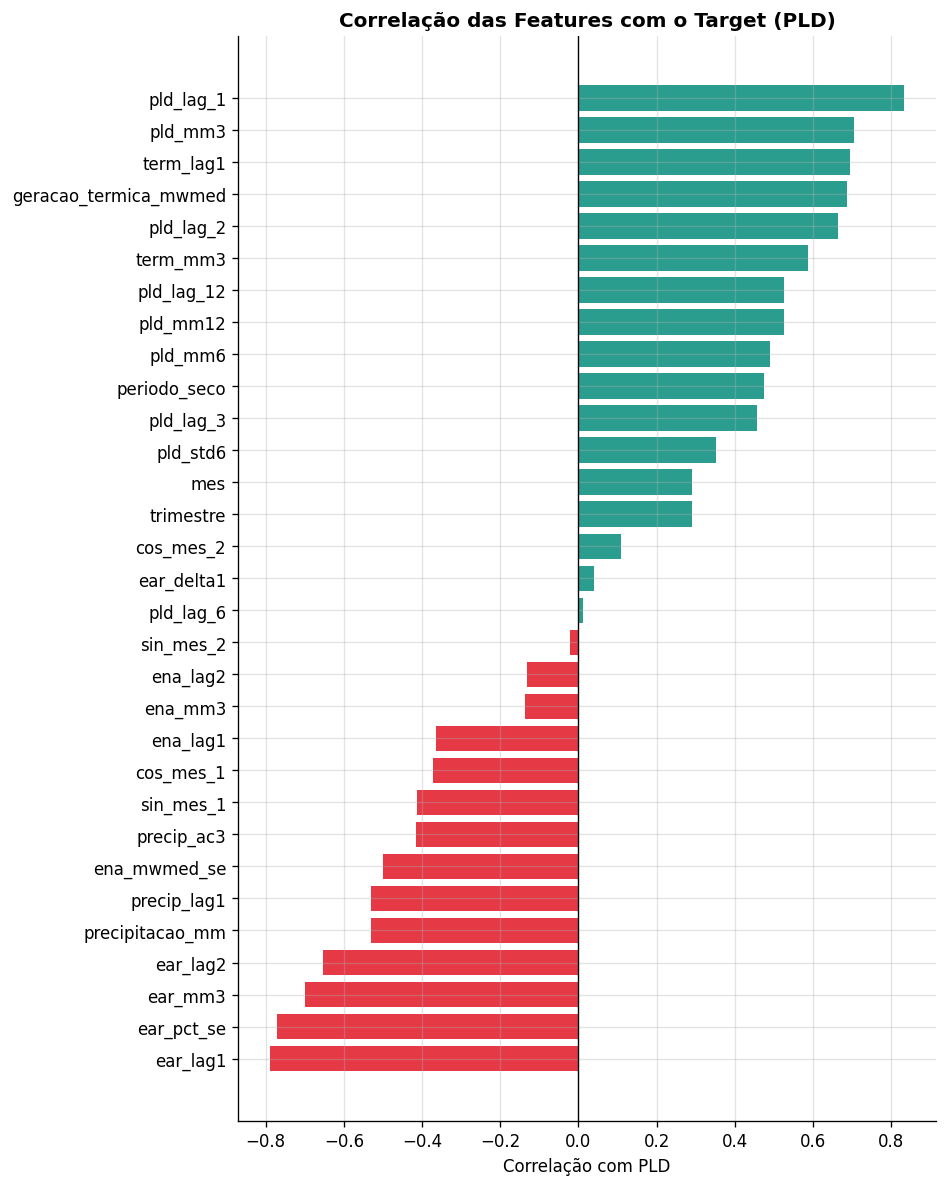

In [7]:
feature_cols = [c for c in df_model.columns
                if c not in ['din_referencia', 'val_pld', 'ano']]

corr_target = (df_model[feature_cols + ['val_pld']]
               .corr()['val_pld']
               .drop('val_pld')
               .sort_values())

fig, ax = plt.subplots(figsize=(8, 10))
colors = ['#E63946' if v < 0 else '#2A9D8F' for v in corr_target]
ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor='none')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Correlação com PLD')
ax.set_title('Correlação das Features com o Target (PLD)', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fe_01_correlacao_features.png', bbox_inches='tight')
plt.show()


## 7. Persistência do Dataset de Modelagem

In [8]:
df_model.to_parquet(PROC_DIR / 'dataset_modelagem.parquet', index=False)
df_model.to_csv(PROC_DIR / 'dataset_modelagem.csv', index=False)

print(f"✅ Dataset salvo em data/processed/dataset_modelagem.parquet")
print(f"   Shape: {df_model.shape}")
print(f"   Features: {len(feature_cols)}")
print(f"   Target: val_pld")
print(f"\nColunas finais:")
for i, c in enumerate(df_model.columns, 1):
    print(f"  {i:2d}. {c}")


✅ Dataset salvo em data/processed/dataset_modelagem.parquet
   Shape: (108, 34)
   Features: 31
   Target: val_pld

Colunas finais:
   1. din_referencia
   2. val_pld
   3. ear_pct_se
   4. ena_mwmed_se
   5. geracao_termica_mwmed
   6. precipitacao_mm
   7. ano
   8. mes
   9. trimestre
  10. sin_mes_1
  11. cos_mes_1
  12. sin_mes_2
  13. cos_mes_2
  14. periodo_seco
  15. pld_lag_1
  16. pld_lag_2
  17. pld_lag_3
  18. pld_lag_6
  19. pld_lag_12
  20. pld_mm3
  21. pld_mm6
  22. pld_mm12
  23. pld_std6
  24. ear_lag1
  25. ear_lag2
  26. ear_delta1
  27. ear_mm3
  28. ena_lag1
  29. ena_lag2
  30. ena_mm3
  31. term_lag1
  32. term_mm3
  33. precip_lag1
  34. precip_ac3
